# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


### Title: Mushroom Classification: Predicting Edibility 

### Description
This project focuses on building a machine learning model to classify mushrooms as either edible or poisonous based on their physical characteristics. The dataset contains categorical features describing mushroom traits such as cap shape, odor, gill size, and color. The goal is to identify the most predictive features and build a model that accurately classifies mushrooms.

### About The Dataset
~8,000+ mushroom samples
~23 features (all categorical)
~Target
    - e = edible
    - p = poisonous

## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [67]:
import pandas as pd

df = pd.read_csv("mushrooms.csv")

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [68]:
df.shape

df.isnull().sum()

df.dtypes

for col in df.columns:
    print(col, df[col].nunique())

class 2
cap-shape 6
cap-surface 4
cap-color 10
bruises 2
odor 9
gill-attachment 2
gill-spacing 2
gill-size 2
gill-color 12
stalk-shape 2
stalk-root 5
stalk-surface-above-ring 4
stalk-surface-below-ring 4
stalk-color-above-ring 9
stalk-color-below-ring 9
veil-type 1
veil-color 4
ring-number 3
ring-type 5
spore-print-color 9
population 6
habitat 7


### Data Overview
The dataset contains 8124 observations and 23 features. There are no missing values present in the dataset, indicating that it is clean and ready for analysis. All features in the dataset are categorical variables representing physical characteristics of mushrooms.

The target variable is "class", which indicates whether a mushroom is edible (e) or poisonous (p). Each feature has a limited number of unique values, making the dataset suitable for classification using machine learning models.

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

In [69]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [70]:
df['class'].value_counts()
df['class'].value_counts(normalize=True)

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64

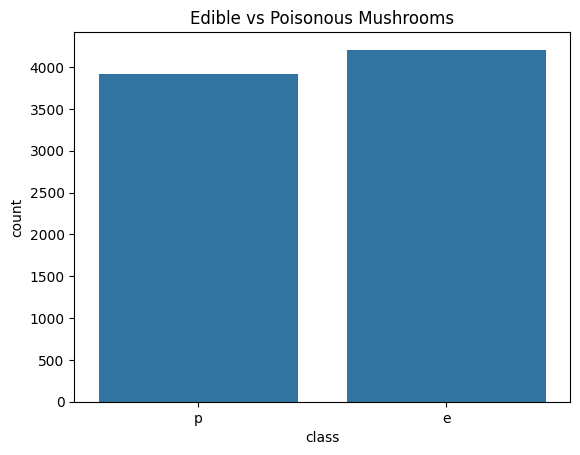

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='class', data=df)
plt.title("Edible vs Poisonous Mushrooms")
plt.show()

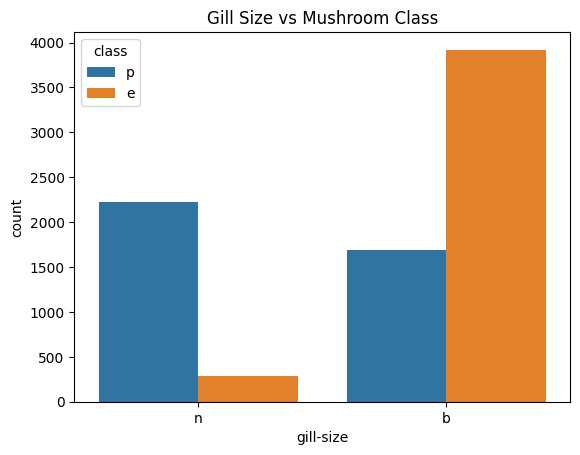

In [72]:
sns.countplot(x='gill-size', hue='class', data=df)
plt.title("Gill Size vs Mushroom Class")
plt.show()

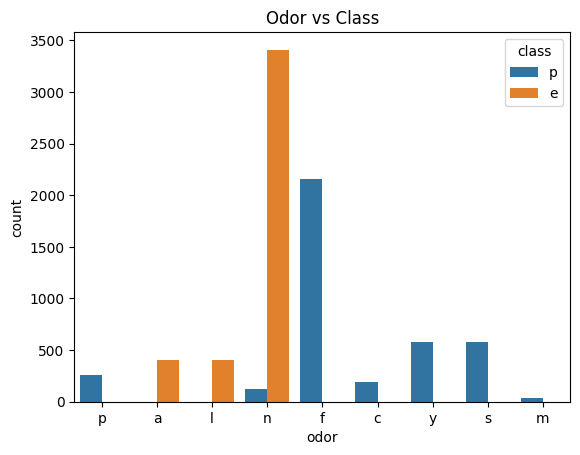

In [73]:
sns.countplot(x='odor', hue='class', data=df)
plt.title("Odor vs Class")
plt.show()

### Insight: Gill Size

Gill size also shows differences between edible and poisonous mushrooms. While not as strong as odor, it still contributes to classification and helps the model distinguish between classes.

Overall, the visualizations show that certain features have a stronger relationship with mushroom classification than others. For example, odor appears to be highly predictive, while features like gill size show moderate differences between classes. These patterns suggest that some variables will have more influence on the machine learning model than others.

### Target Distribution
The dataset is relatively balanced between edible and poisonous mushrooms. This is important for machine learning because it prevents the model from being biased toward one class. A balanced dataset helps improve the accuracy and reliability of the classification model.

In [74]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [75]:
X = df.drop('class', axis=1)
y = df['class']

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Confusion Matrix

The confusion matrix shows how well the model classified each class. The model correctly predicted most of the edible and poisonous mushrooms, with very few misclassifications. This further confirms the high performance of the model.

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

### Label Encoding
Label encoding was applied to convert categorical variables into numerical values. This process assigns a unique integer to each category, allowing machine learning algorithms to process the data. Since all features were categorical, this step was essential for preparing the dataset for modeling. No missing values or outliers were detected, so no additional cleaning was required.

In [76]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    df[col] = le.fit_transform(df[col])

df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


### Machine Learning Explanation 
A decision tree classifier was selected for this task because it performs well on categorical data and is easy to interpret. Decision trees work by splitting the data based on feature values, creating a structure that separates the classes step by step. This makes them well-suited for classification problems like this one.

In [77]:
X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [78]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

## Training

The model used in this project is a Decision Tree Classifier from scikit-learn. The dataset was split into training and testing sets using an 80/20 split.

Since Decision Trees do not train using epochs like neural networks, there are no training curves such as loss vs epoch. The model was trained in a single step using the fit() function.

Training was completed on a local machine using Python and Jupyter Notebook and took less than a few seconds due to the relatively small dataset size.

The model does not require iterative stopping criteria, as it builds the tree based on the data structure. One potential concern is overfitting, since Decision Trees can perfectly fit training data.

### Model Evaluation
The model achieved very high accuracy, indicating that it was able to correctly classify most of the mushrooms. The confusion matrix further confirms this performance, showing very few misclassifications. This suggests that the features in the dataset provide clear distinctions between edible and poisonous mushrooms.

In [79]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

### Conclusion 
In this project, a decision tree classifier was used to classify mushrooms based on their features. Initial data exploration showed that certain features had clear relationships with the target variable, which contributed to the model’s high performance.

The model achieved very high accuracy; however, this may indicate overfitting or that the dataset is highly separable. In real-world scenarios, data is often more complex, so models typically require further validation to ensure they generalize well to new data.

## Future Work
The next step would be to test additional machine learning models, such as Random Forest, Logistic Regression, or K-Nearest Neighbors, to compare performance. Another future study could focus on feature importance to determine which mushroom characteristics are the strongest predictors of edibility. Since the model achieved very high accuracy, future work should also test the model on new mushroom datasets to see if it generalizes well outside of this dataset.

## How to Reproduce Results
To reproduce the results, download the Mushroom Classification dataset from Kaggle and place the `mushrooms.csv` file in the same folder as the Jupyter notebook. Then open the notebook and run all cells from top to bottom. The notebook loads the dataset, checks the data structure, visualizes important features, encodes categorical variables, trains a Decision Tree Classifier, and evaluates the model using accuracy and a confusion matrix.

## Overview of Files in Repository
- `Kaggle Tabular Data.ipynb`: Main notebook containing data loading, exploratory data analysis, preprocessing, model training, and evaluation.
- `mushrooms.csv`: Dataset used for the project.
- `README.md`: Project overview, instructions, results summary, and citations.

## Software Setup
This project uses Python and Jupyter Notebook. The required packages are:

- pandas
- matplotlib
- seaborn
- scikit-learn

### Data

The dataset can be downloaded from Kaggle:
https://www.kaggle.com/datasets/uciml/mushroom-classification/data

The dataset contains mushroom characteristics and a target column called class, where e represents edible and p represents poisonous. Since the dataset is mostly categorical, label encoding was used to convert the values into numeric form before training.

### Training

The model can be trained by running the training section of the notebook. The project uses a Decision Tree Classifier from scikit-learn. The data is split into training and testing sets using an 80/20 split.

### Performance Evaluation

The model is evaluated using accuracy score and a confusion matrix. These metrics show how well the model classified edible and poisonous mushrooms.

## Performance Comparison

The primary performance metric used in this project is accuracy.

| Model          | Accuracy |
|----------------|----------|
| Decision Tree  | 1.00     |

The model achieved 100% accuracy on the test set, meaning it correctly classified all mushrooms as edible or poisonous.

A confusion matrix was also used to evaluate performance. The matrix shows that there were no misclassifications, indicating strong performance.

While the results are very high, this may suggest that the dataset is highly separable or that the model is overfitting. In real-world applications, further validation would be needed.

### Citations
Kaggle Mushroom Classification Dataset: https://www.kaggle.com/datasets/uciml/mushroom-classification/data
UCI Machine Learning Repository Mushroom Dataset